This notebook contains a simplified and shortened analysis, that matches what was done in the paper "_Measurements of Forbush decrease events at the center of the South Atlantic Magnetic Anomaly with Muon detectors_" by J. Molina et. al.

The code is kept simple and procedural, so it can be more easily followed by anyone without expertise in production style code.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import matplotlib.dates as mdates

Load Data
df correspond to first event analysis - Data used is corrected by pressure and Teff

In [ ]:
df = pd.read_csv('first_period/fiunamuons_may_junecorrected.csv')
df['datetime'] = pd.to_datetime(df.datetime)

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['muons'] = pd.to_numeric(df['muons'], errors='coerce')


In [ ]:
df['muons'] = pd.to_numeric(df['muons'], errors='coerce')
df = df.set_index('datetime').resample('1H').mean()

In [ ]:
df

,muons,IoTPC,lab_temp,external_pressure,TMP_MSS
datetime,,,,,
2024-05-07 00:00:00,1896.433333,1906.966408,296.083333,990.766667,263.617805
2024-05-07 01:00:00,1885.830508,1897.721742,296.090000,991.033333,263.560956
2024-05-07 02:00:00,1890.017241,1903.806843,296.213333,991.116667,263.504107
2024-05-07 03:00:00,1880.706897,1894.690300,295.920000,991.241667,263.447258
2024-05-07 04:00:00,1885.983333,1896.445811,295.390000,991.108333,263.353770
...,...,...,...,...,...
2024-06-24 17:00:00,1877.516667,1876.860524,290.535000,999.858333,258.638804
2024-06-24 18:00:00,1878.433333,1877.151311,290.401667,999.783333,258.611486
2024-06-24 19:00:00,NaN,NaN,NaN,NaN,NaN


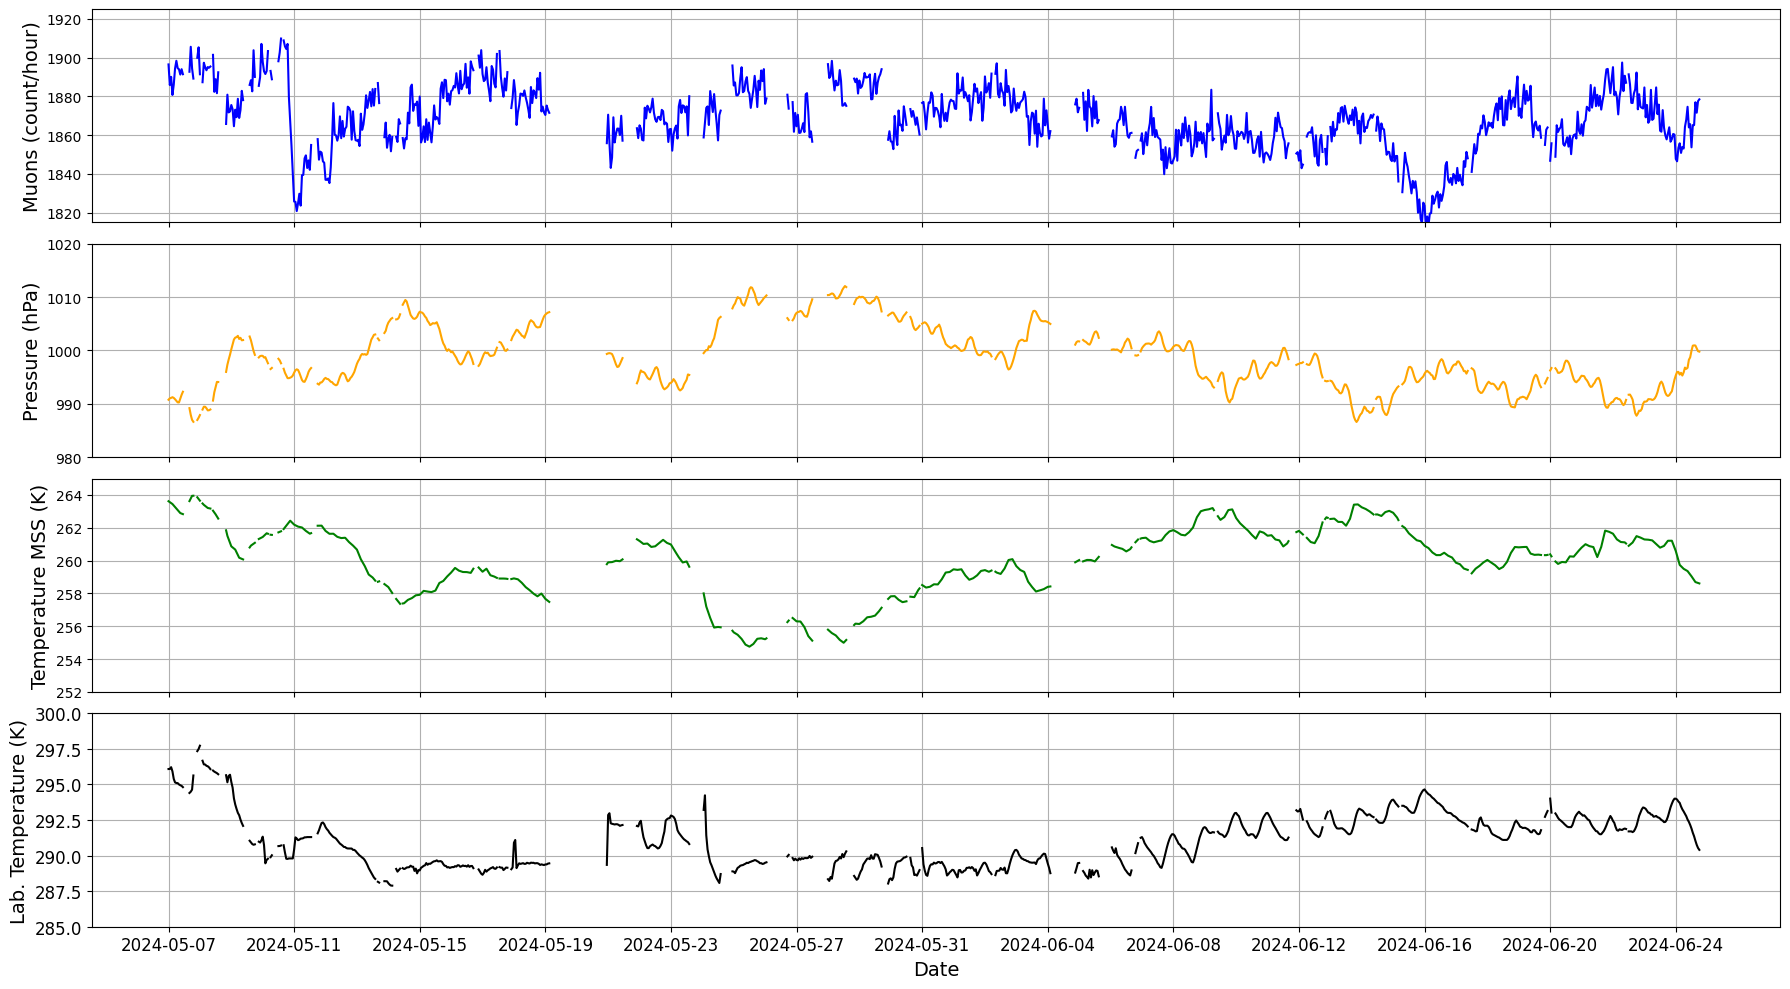

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

datos = [
    (df, ['muons'],             'Muons (count/hour)',               'blue'),
    (df, ['external_pressure'], 'Pressure (hPa)',      'orange'),
    (df, ['TMP_MSS'],           'Temperature MSS (K)', 'green'),
    (df, ['lab_temp'],           'Lab. Temperature (K)', 'k')
]

limites = [
    (1815, 1925),
    (980, 1020),
    (252, 265),
    (285, 300)
]

for i, (dataframe, variables, ylabel, color) in enumerate(datos):
    for var in variables:
        axs[i].plot(dataframe.index, dataframe[var], label=var, color=color)

    axs[i].set_ylabel(ylabel, fontsize=14)
    axs[i].grid(True)


    axs[i].set_ylim(limites[i])

axs[-1].xaxis.set_major_locator(mdates.DayLocator(interval=4))
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

axs[-1].set_xlabel('Date', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('muons_may_june_pressure_temp_wei_new.png', dpi = 300)
plt.subplots_adjust(hspace=0.1)
plt.show()


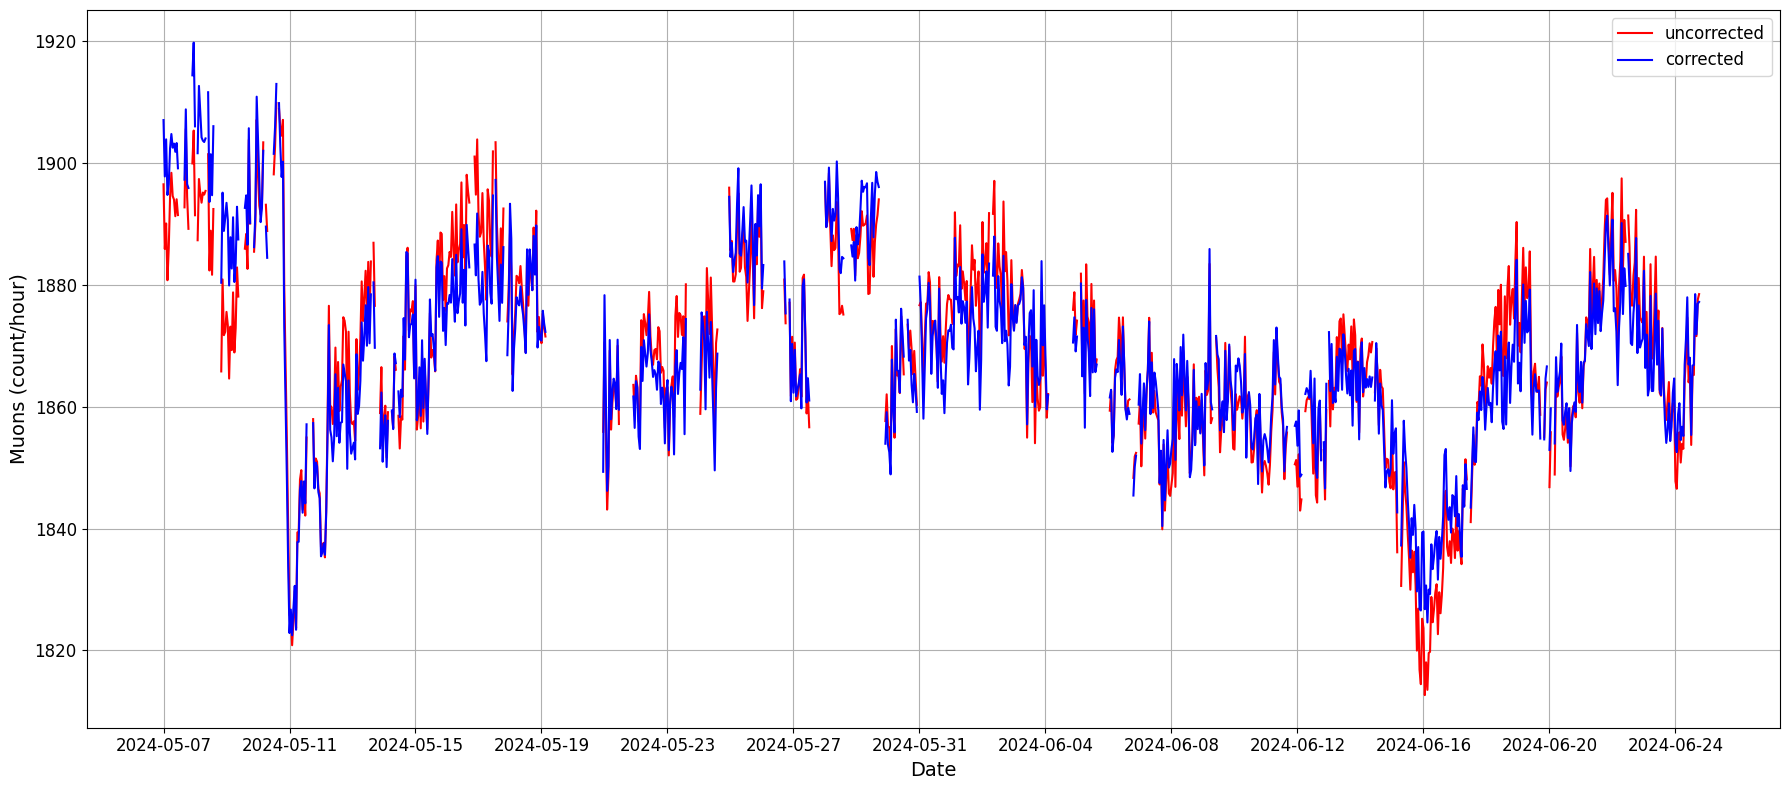

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_color('black')

ax.plot(df.index,df['muons'], label ='uncorrected', color = 'red')
ax.plot(df.index,df['IoTPC'],label = 'corrected', color = 'blue')
ax.set_ylabel('Muons (count/hour)', fontsize = 14)
ax.set_xlabel('Date', fontsize = 14)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('muons_may_june_hourly_corrected_uncorrected_new.png', dpi = 300)
plt.show()


Mexico Detector Analysis

In [ ]:
neutron = pd.read_csv('first_period/neutrons.csv')
neutron['datetime'] = pd.to_datetime(neutron.timestamp)
neutron.set_index(['datetime'], drop=True,inplace = True)
neutron

,timestamp,neutron_counts_sec_avg
datetime,,
2024-05-01 12:00:00+00:00,2024-05-01 12:00:00+00:00,220.316
2024-05-01 13:00:00+00:00,2024-05-01 13:00:00+00:00,220.466
2024-05-01 14:00:00+00:00,2024-05-01 14:00:00+00:00,221.184
2024-05-01 15:00:00+00:00,2024-05-01 15:00:00+00:00,219.385
2024-05-01 16:00:00+00:00,2024-05-01 16:00:00+00:00,219.619
...,...,...
2024-06-25 19:00:00+00:00,2024-06-25 19:00:00+00:00,222.587
2024-06-25 20:00:00+00:00,2024-06-25 20:00:00+00:00,221.703
2024-06-25 21:00:00+00:00,2024-06-25 21:00:00+00:00,220.856


DST Analysis

In [ ]:
dst = pd.read_csv('first_period/dst.csv')
dst['datetime'] = pd.to_datetime(dst.timestamp)
dst.set_index(['datetime'], drop=True,inplace = True)
dst

,timestamp,dst
datetime,,
2024-01-01 00:00:00,2024-01-01 00:00:00,4.0
2024-01-01 01:00:00,2024-01-01 01:00:00,5.0
2024-01-01 02:00:00,2024-01-01 02:00:00,7.0
2024-01-01 03:00:00,2024-01-01 03:00:00,8.0
2024-01-01 04:00:00,2024-01-01 04:00:00,7.0
...,...,...
2024-06-26 15:00:00,2024-06-26 15:00:00,-15.0
2024-06-26 16:00:00,2024-06-26 16:00:00,-11.0
2024-06-26 17:00:00,2024-06-26 17:00:00,-7.0


In [ ]:
flag0 = np.logical_and(df.index >= '2024-05-07 00:00:00', df.index <= '2024-05-19 23:59:00')
df = df[flag0]

In [ ]:
df['pc_muons'] = (df['IoTPC'] - df['IoTPC'].mean())/df['IoTPC'].mean() *100

In [ ]:
df['pc_muons']

datetime
2024-05-07 00:00:00    2.078847
2024-05-07 01:00:00    1.583985
2024-05-07 02:00:00    1.909717
2024-05-07 03:00:00    1.421713
2024-05-07 04:00:00    1.515685
                         ...   
2024-06-24 17:00:00    0.467295
2024-06-24 18:00:00    0.482861
2024-06-24 19:00:00         NaN
2024-06-24 20:00:00         NaN
2024-06-24 21:00:00    0.495218
Freq: h, Name: pc_muons, Length: 1174, dtype: float64

In [ ]:
flag2 = np.logical_and(dst.index >= '2024-05-07 00:00:00', dst.index <= '2024-06-24 21:59:00')
dst = dst[flag2]

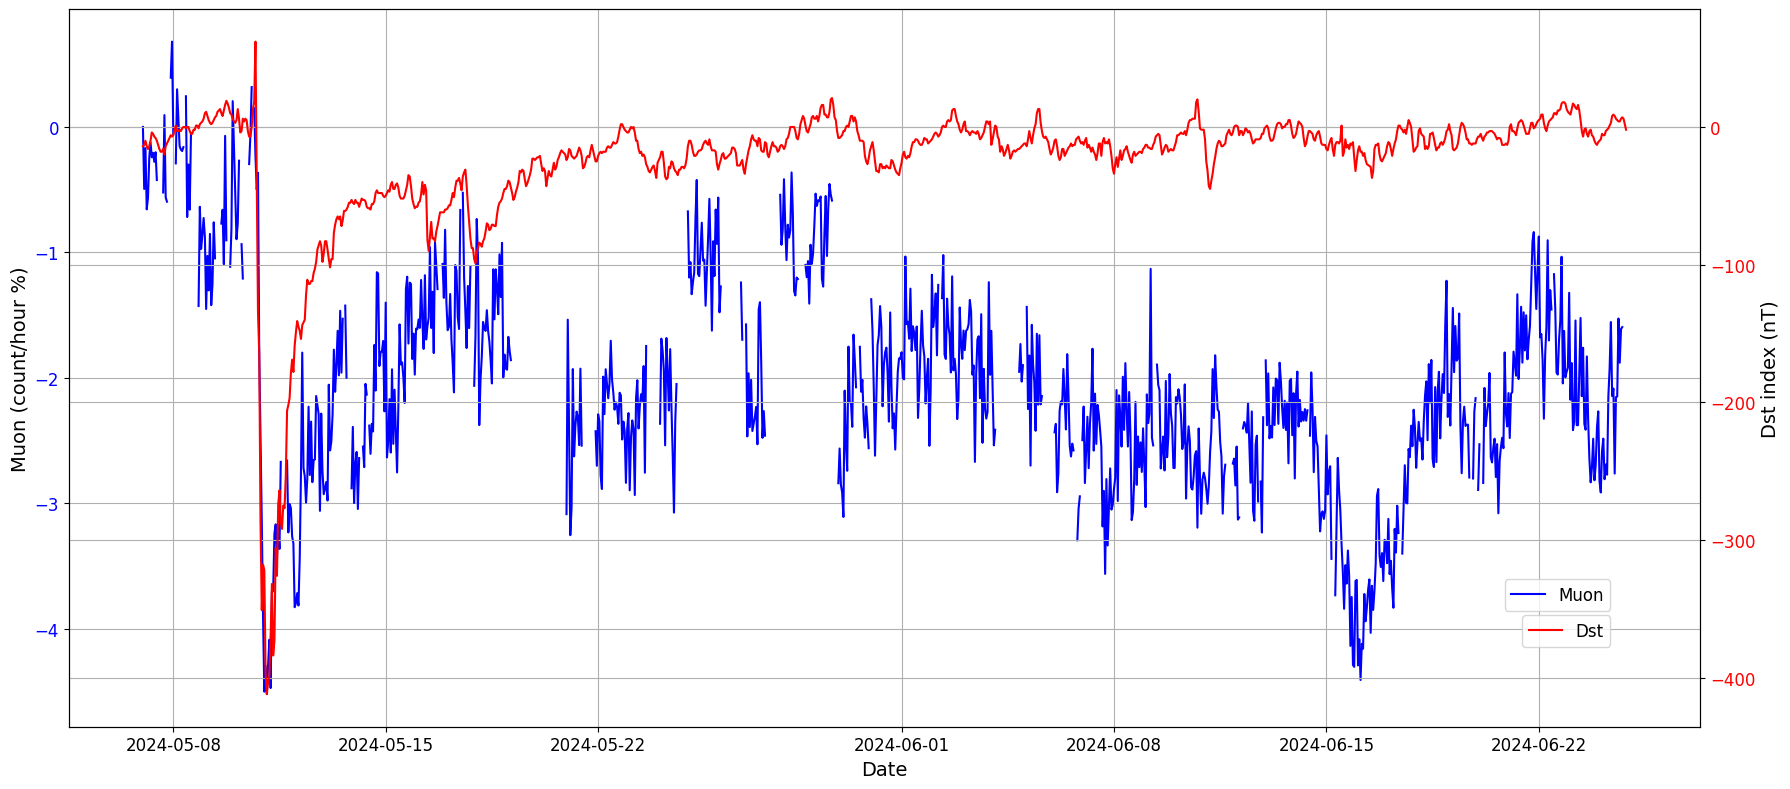

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(18, 8))


fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_color('black')

ax.plot(df.index, df['pc_muons'] , label='Muon', color='blue')
ax.set_ylabel('Muon (count/hour %)', fontsize=14)
ax.tick_params(axis='y', labelcolor='blue')
ax.set_xlabel('Date', fontsize=14)



ax2 = ax.twinx()
ax2.plot(dst.index, dst['dst'], label='Dst', color='red')
ax2.set_ylabel('Dst index (nT)', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_xlabel('Date', fontsize=14)

ax.legend(loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=12)
ax2.legend(loc="lower right", bbox_to_anchor=(0.95, 0.10), fontsize=12)




ax.grid(visible=True, which='both')
ax2.grid(visible=True, which='both')

ax.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('muons_vs_dst_new_first_full_period.png', dpi = 300)
plt.show()

In [ ]:
flag3 = np.logical_and(neutron.index >= '2024-05-07 00:00:00', neutron.index <= '2024-05-19 23:59:00')
neutron = neutron[flag3]

In [ ]:
neutron['pc_neutron'] = (neutron['neutron_counts_sec_avg'] - neutron['neutron_counts_sec_avg'].mean())/neutron['neutron_counts_sec_avg'].mean() *100

In [ ]:
neutron.head()

,timestamp,neutron_counts_sec_avg,pc_neutron
datetime,,,
2024-05-07 00:00:00+00:00,2024-05-07 00:00:00+00:00,219.411,2.109866
2024-05-07 01:00:00+00:00,2024-05-07 01:00:00+00:00,219.709,2.248550
2024-05-07 02:00:00+00:00,2024-05-07 02:00:00+00:00,219.859,2.318357
2024-05-07 03:00:00+00:00,2024-05-07 03:00:00+00:00,220.032,2.398868
2024-05-07 04:00:00+00:00,2024-05-07 04:00:00+00:00,219.779,2.281127


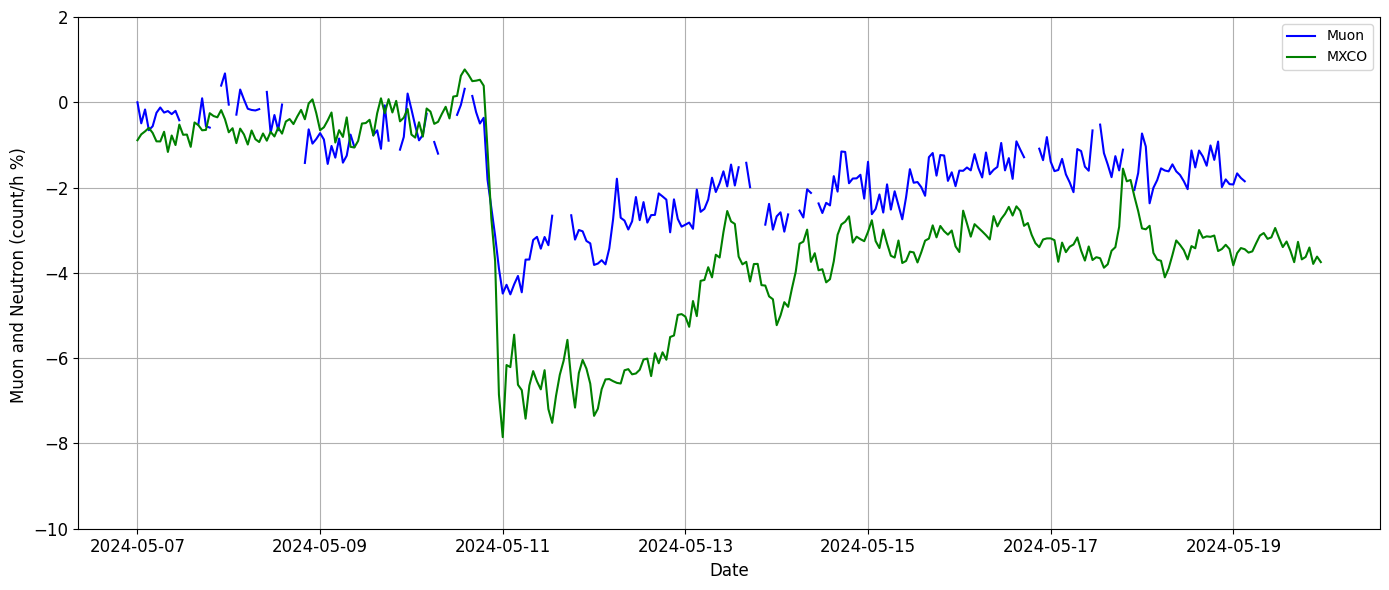

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index,df['pc_muons']  ,label = 'Muon', color = 'blue')
ax.plot(neutron.index, neutron['pc_neutron'], label = 'MXCO', color = 'green')
ax.set_ylabel('Muon and Neutron (count/h %) ', fontsize = 12)
ax.set_xlabel('Date', fontsize = 12)
ax.legend()
plt.ylim(-10,2)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.grid(True)
plt.savefig('muons_may_june_hourly_muon_neutron_new.png', dpi = 300)
plt.show()

Analysis reference to second period
df2 correspond to muons data corrected by pressure and Teff


In [ ]:
df2 = pd.read_csv('muons_sep_oct.csv')
df2['datetime'] = pd.to_datetime(df2.datetime)

In [ ]:
df2['datetime'] = pd.to_datetime(df2['datetime'])
df2['muons'] = pd.to_numeric(df2['muons'], errors='coerce')


In [ ]:
df2['muons'] = pd.to_numeric(df2['muons'], errors='coerce')
df2 = df2.set_index('datetime').resample('1H').mean()

C:\Users\Dell\AppData\Local\Temp\ipykernel_4956\2146151424.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df2 = df2.set_index('datetime').resample('1H').mean()


In [ ]:
def remove_outliers(df_in, col_name):
  q1,q3 = np.percentile(df_in.loc[:,col_name],[25,75])
  iqr = q3 - q1
  upper_limit = q3 + 0.5 * iqr
  lower_limit = q1 - 0.5 * iqr
  df_in.loc[(df_in[col_name] < lower_limit) | (df_in[col_name] > upper_limit), col_name] = np.nan
  return df_in

In [ ]:
remove_outliers(df2, 'lab_temp')

,Unnamed: 0,muons,IoTPC,lab_temp,Ps,TMP_MSS
datetime,,,,,,
2024-09-16 18:00:00,0.0,1847.299000,1879.493446,293.081667,1008.604806,258.929056
2024-09-16 19:00:00,1.0,1858.547000,1889.508410,293.230000,1007.630717,259.072807
2024-09-16 20:00:00,2.0,1851.611695,1880.664475,293.315000,1006.656627,259.216559
2024-09-16 21:00:00,3.0,1864.078500,1891.092128,293.326667,1005.682538,259.360310
2024-09-16 22:00:00,4.0,1843.654500,1873.902597,293.245000,1007.464887,259.322617
...,...,...,...,...,...,...
2024-10-31 07:00:00,1069.0,1852.532586,1839.567918,290.091667,996.941997,261.749244
2024-10-31 08:00:00,1070.0,1847.502500,1836.207547,290.015000,997.845594,261.616537
2024-10-31 09:00:00,1071.0,1860.153051,1850.504656,289.951667,998.749191,261.483830


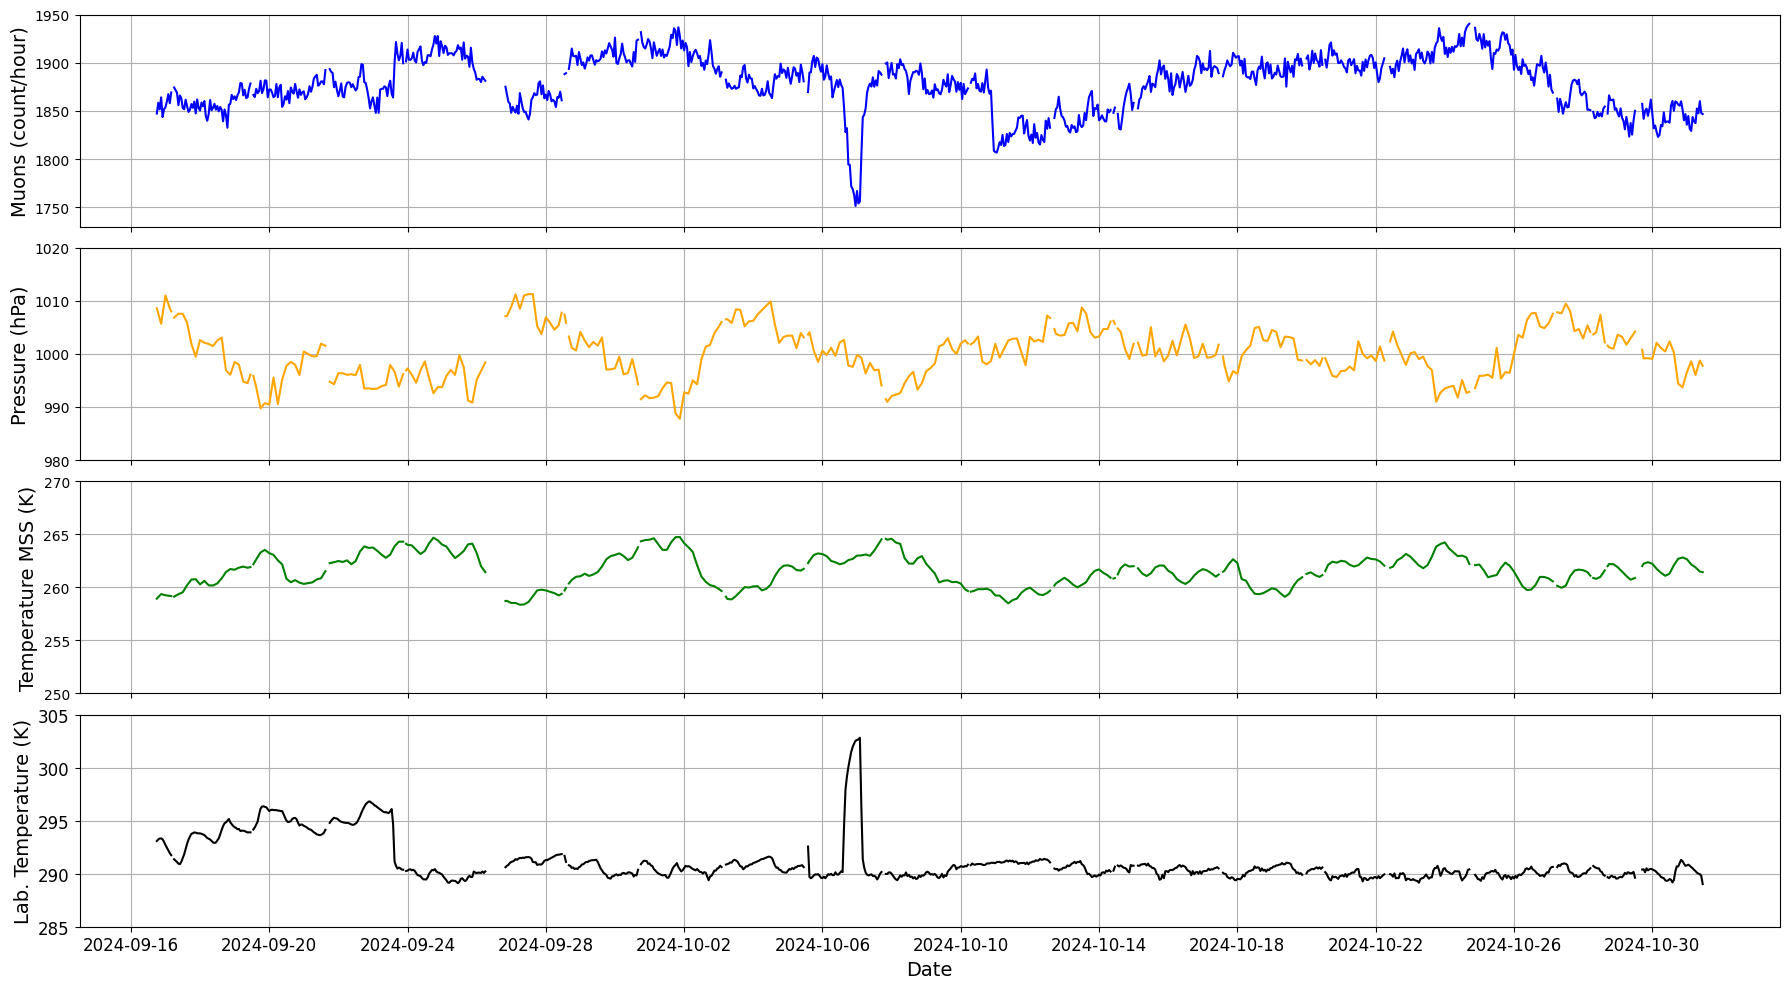

In [ ]:
fig, axs = plt.subplots(4, 1, figsize=(18, 10), sharex=True)

datos = [
    (df2, ['muons'],             'Muons (count/hour)',               'blue'),
    (df2, ['Ps'], 'Pressure (hPa)',      'orange'),
    (df2, ['TMP_MSS'],           'Temperature MSS (K)', 'green'),
    (df2, ['lab_temp'],           'Lab. Temperature (K)', 'k')
]

limites = [
    (1730, 1950),
    (980, 1020),
    (250, 270),
    (285, 305)
]

for i, (dataframe, variables, ylabel, color) in enumerate(datos):
    for var in variables:
        axs[i].plot(dataframe.index, dataframe[var], label=var, color=color)

    axs[i].set_ylabel(ylabel, fontsize=14)
    axs[i].grid(True)


    axs[i].set_ylim(limites[i])

axs[-1].xaxis.set_major_locator(mdates.DayLocator(interval=4))
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

axs[-1].set_xlabel('Date', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('muons_sep_oct_pressure_temp_wei_new.png', dpi = 300)
plt.subplots_adjust(hspace=0.1)
plt.show()

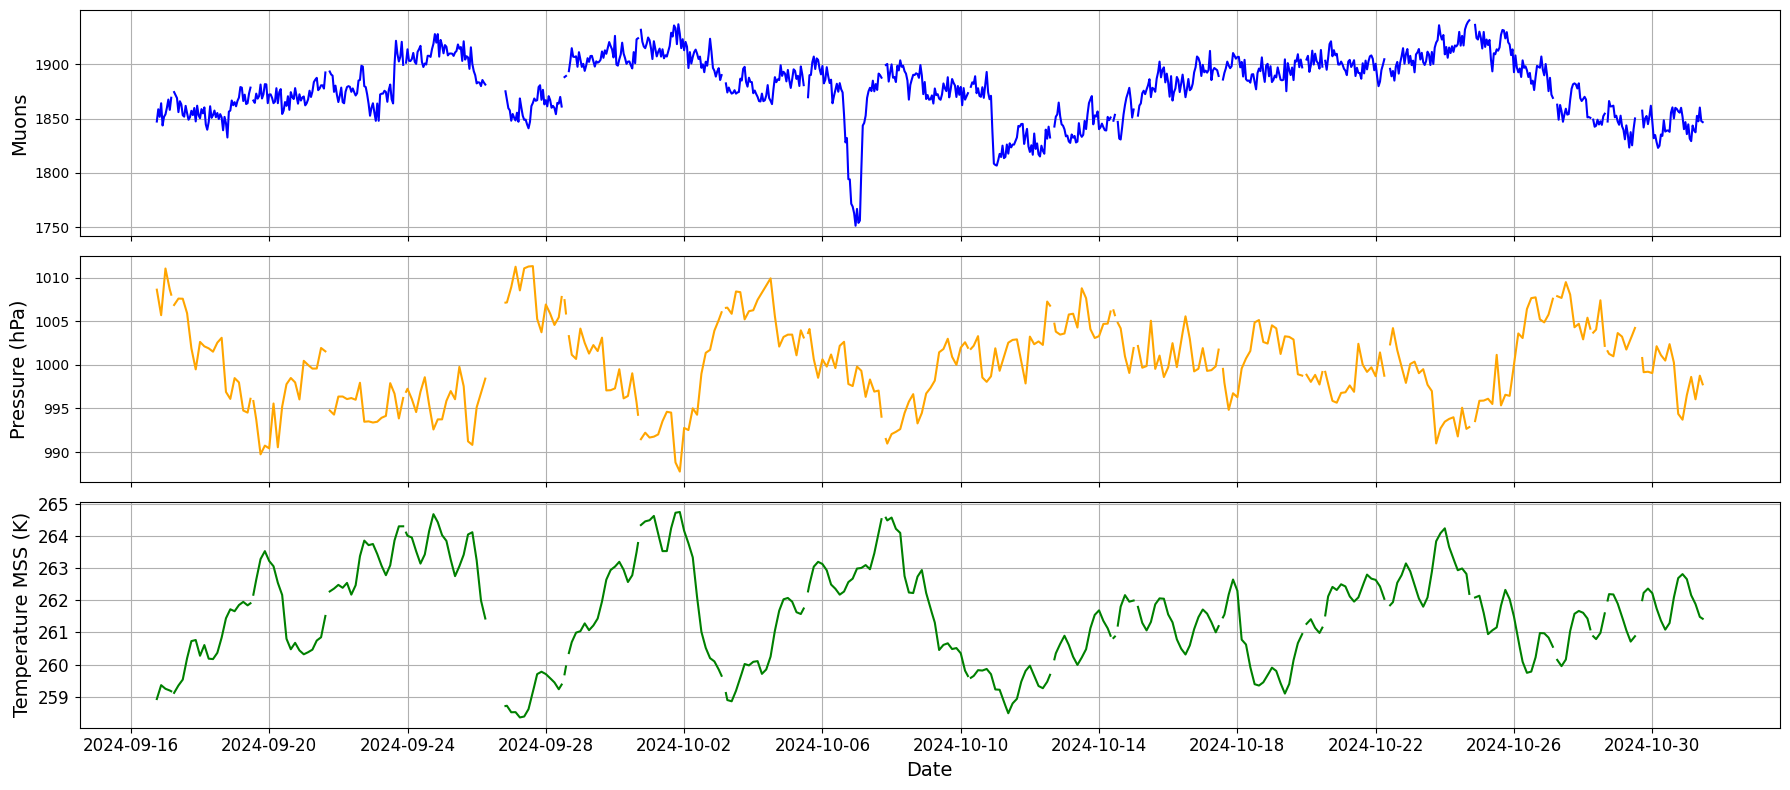

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(18, 8), sharex=True)

datos = [
    (df2, ['muons'],             'Muons',               'blue'),
    (df2, ['Ps'], 'Pressure (hPa)',      'orange'),
    (df2, ['TMP_MSS'],           'Temperature MSS (K)', 'green')
]

for i, (dataframe, variables, ylabel, color) in enumerate(datos):
    for var in variables:
        axs[i].plot(
            dataframe.index,
            dataframe[var],
            label=var,
            color=color
        )
    axs[i].set_ylabel(ylabel, fontsize=14)
    axs[i].grid(True)

    #if i == 0:
    #    axs[i].legend(loc='upper right', fontsize=12)


axs[-1].xaxis.set_major_locator(mdates.DayLocator(interval=4))
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


axs[-1].set_xlabel('Date', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig('muons_sep_oct_pressure_temp_wei_new.png', dpi = 300)
plt.show()

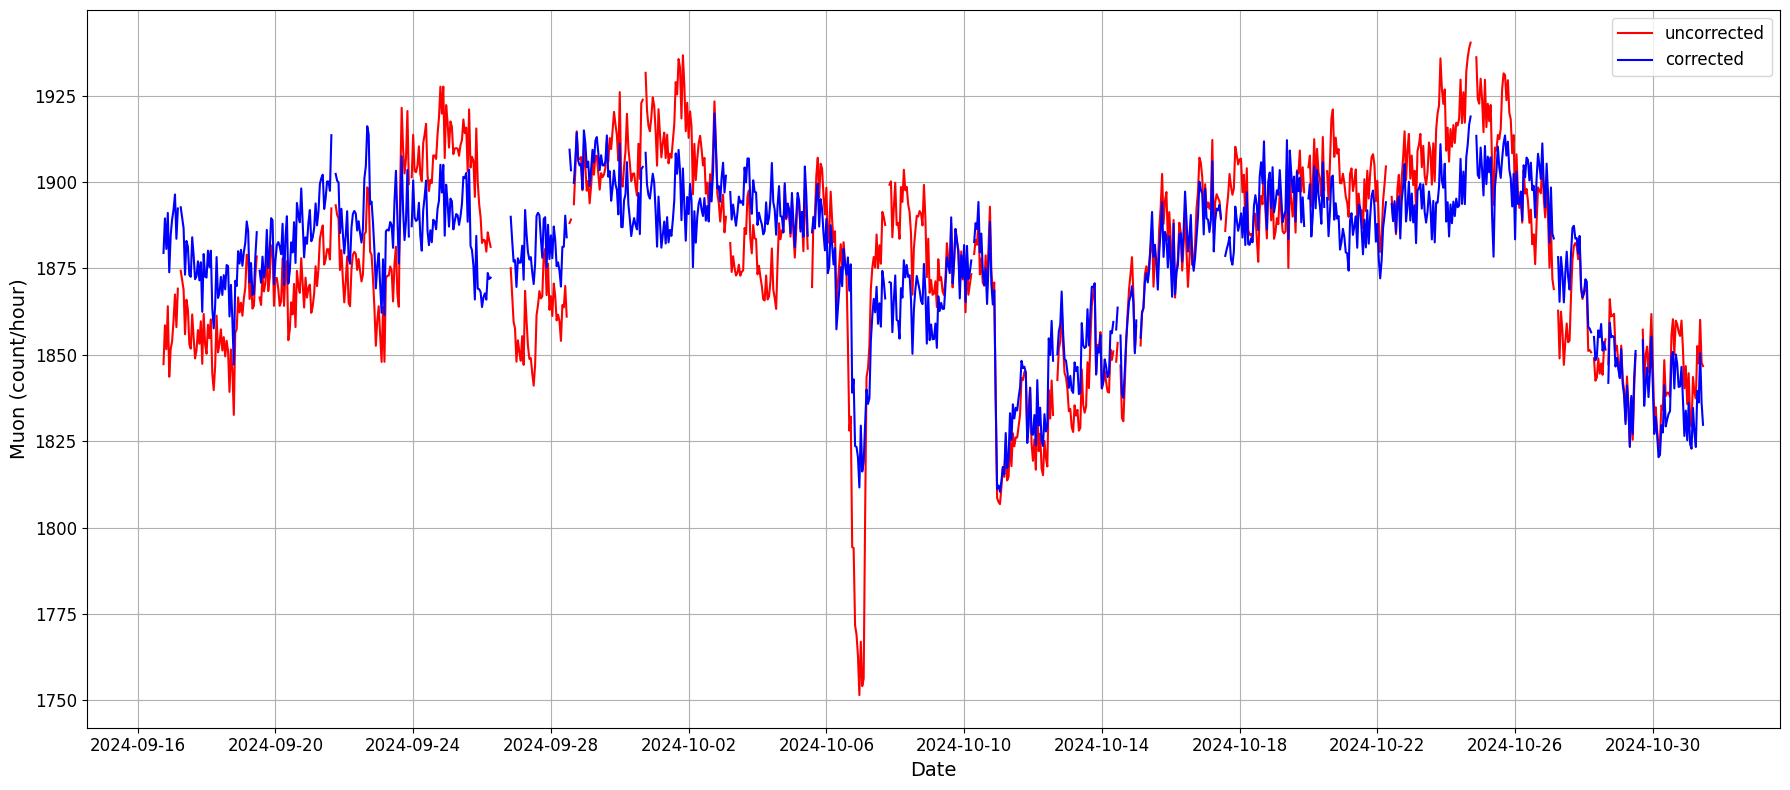

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_color('black')

ax.plot(df2.index,df2['muons'], label ='uncorrected', color = 'red')
ax.plot(df2.index,df2['IoTPC'],label = 'corrected', color = 'blue')
ax.set_ylabel('Muon (count/hour)', fontsize = 14)
ax.set_xlabel('Date', fontsize = 14)

ax.xaxis.set_major_locator(mdates.DayLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('muons_set_oct_hourly_corrected_uncorrected_new.png', dpi = 300)
plt.show()


In [ ]:
dst2 = pd.read_csv('second_period/dst_second_period.csv')
dst2['datetime'] = pd.to_datetime(dst2.timestamp)
dst2.set_index(['datetime'], drop=True,inplace = True)
dst2

,timestamp,dst
datetime,,
2024-09-01 00:00:00,2024-09-01 00:00:00,-45
2024-09-01 01:00:00,2024-09-01 01:00:00,-37
2024-09-01 02:00:00,2024-09-01 02:00:00,-32
2024-09-01 03:00:00,2024-09-01 03:00:00,-35
2024-09-01 04:00:00,2024-09-01 04:00:00,-34
...,...,...
2024-10-30 20:00:00,2024-10-30 20:00:00,-9
2024-10-30 21:00:00,2024-10-30 21:00:00,-2
2024-10-30 22:00:00,2024-10-30 22:00:00,6


In [ ]:
flag_dst2 = np.logical_and(dst2.index >= '2024-10-02 18:00:00', dst2.index <= '2024-10-17 23:59:00')
dst2 = dst2[flag_dst2]

In [ ]:
flag_df2 = np.logical_and(df2.index >= '2024-10-02 00:00:00', df2.index <= '2024-10-17 23:59:00')
df2 = df2[flag_df2]

In [ ]:
df2['pc_muons'] = (df2['IoTPC'] - df2['IoTPC'].mean())/df2['IoTPC'].mean() *100

In [ ]:
df2['pc_muons']

datetime
2024-09-16 18:00:00    0.031179
2024-09-16 19:00:00    0.564200
2024-09-16 20:00:00    0.093504
2024-09-16 21:00:00    0.648489
2024-09-16 22:00:00   -0.266379
                         ...   
2024-10-31 07:00:00   -2.093754
2024-10-31 08:00:00   -2.272601
2024-10-31 09:00:00   -1.511674
2024-10-31 10:00:00   -2.272415
2024-10-31 11:00:00   -2.616772
Freq: h, Name: pc_muons, Length: 1074, dtype: float64

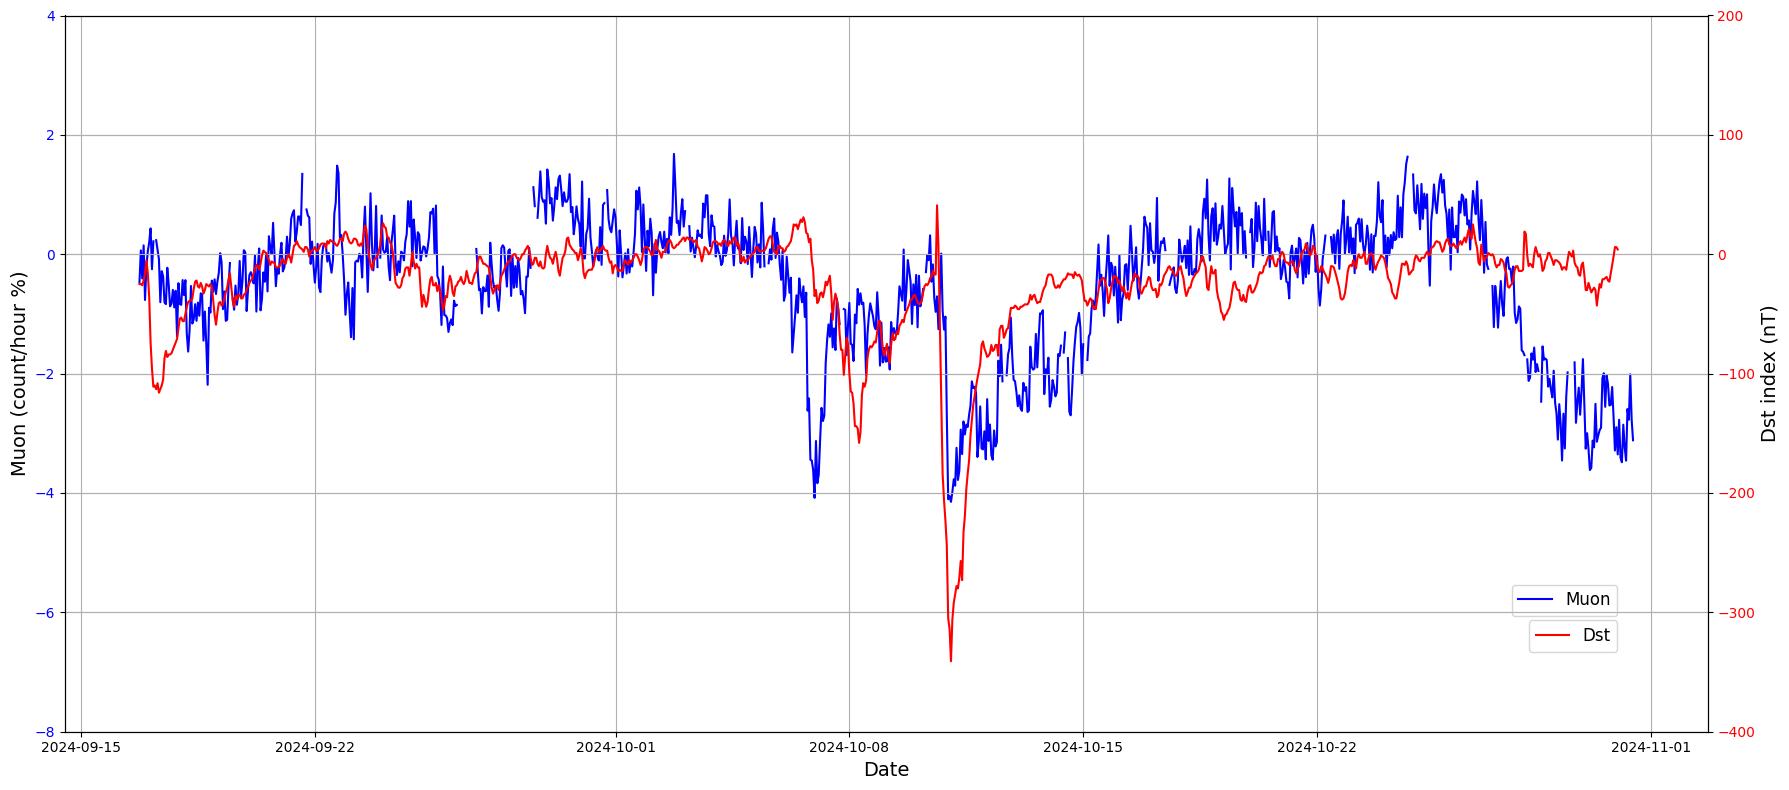

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(18, 8))


fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ax.spines.values():
    spine.set_color('black')

ax.plot(df2.index, df2['pc_muons'] , label='Muon', color='blue')
ax.set_ylabel('Muon (count/hour %)', fontsize=14)
ax.tick_params(axis='y', labelcolor='blue')
ax.set_xlabel('Date', fontsize=14)
ax.set_ylim(-8,4)



ax2 = ax.twinx()
ax2.plot(dst2.index, dst2['dst'], label='Dst', color='red')
ax2.set_ylabel('Dst index (nT)', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_xlabel('Date', fontsize=14)
ax2.set_ylim(-400,200)

ax.legend(loc="lower right", bbox_to_anchor=(0.95, 0.15), fontsize=12)
ax2.legend(loc="lower right", bbox_to_anchor=(0.95, 0.10), fontsize=12)




ax.grid(visible=True, which='both')
ax2.grid(visible=True, which='both')

plt.tight_layout()
plt.savefig('muons_set_oct_dst_full_period_new.png', dpi = 300)

plt.show()

In [ ]:
neutron2 = pd.read_csv('second_period/neutron_second_period.csv', sep = ';')
neutron2['datetime'] = pd.to_datetime(neutron2.datetime)
neutron2.set_index(['datetime'], drop=True,inplace = True)
neutron2

,neutrons
datetime,
2024-09-16 00:00:00,211.176
2024-09-16 01:00:00,211.053
2024-09-16 02:00:00,211.433
2024-09-16 03:00:00,210.306
2024-09-16 04:00:00,210.167
...,...
2024-10-31 19:00:00,198.721
2024-10-31 20:00:00,197.979
2024-10-31 21:00:00,197.759


In [ ]:
flag_df2 = np.logical_and(df2.index >= '2024-10-10 00:00:00', df2.index <= '2024-10-17 23:59:00')
df2 = df2[flag_df2]

In [ ]:
flag_neutron2 = np.logical_and(neutron2.index >= '2024-10-02 00:00:00', neutron2.index <= '2024-10-17 23:59:00')
neutron2 = neutron2[flag_neutron2]